In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV

In [2]:
df = pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
X = df[['TV','Radio','Newspaper']]
y = df['Sales']


In [4]:
#split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
lasso_cv = LassoCV(random_state=42, max_iter=5000)
lasso_cv.fit(X_train, y_train)

print("Best alpha selected:", lasso_cv.alpha_)

Best alpha selected: 0.05951504753162921


In [7]:
y_pred = lasso_cv.predict(X_test)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))
mae

R2 Score: 0.8991773130727259


1.4554793520384173

Alpha = 0.0010 | Coefficients = [3.76324261 2.79164909 0.05524889]
Alpha = 0.0013 | Coefficients = [3.76298201 2.79146572 0.05505076]
Alpha = 0.0016 | Coefficients = [3.76264993 2.79123204 0.05479827]
Alpha = 0.0021 | Coefficients = [3.76222676 2.79093428 0.05447654]
Alpha = 0.0026 | Coefficients = [3.76168754 2.79055485 0.05406657]
Alpha = 0.0034 | Coefficients = [3.76100042 2.79007135 0.05354415]
Alpha = 0.0043 | Coefficients = [3.76012483 2.78945523 0.05287844]
Alpha = 0.0055 | Coefficients = [3.7590091  2.78867013 0.05203015]
Alpha = 0.0070 | Coefficients = [3.75756995 2.78772606 0.05092765]
Alpha = 0.0089 | Coefficients = [3.75575873 2.78644965 0.04955082]
Alpha = 0.0113 | Coefficients = [3.75345075 2.78482316 0.04779635]
Alpha = 0.0144 | Coefficients = [3.75050975 2.78275057 0.04556068]
Alpha = 0.0183 | Coefficients = [3.7467621  2.78010951 0.04271182]
Alpha = 0.0234 | Coefficients = [3.74198656 2.77674407 0.03908159]
Alpha = 0.0298 | Coefficients = [3.73590121 2.77245558 0.03445

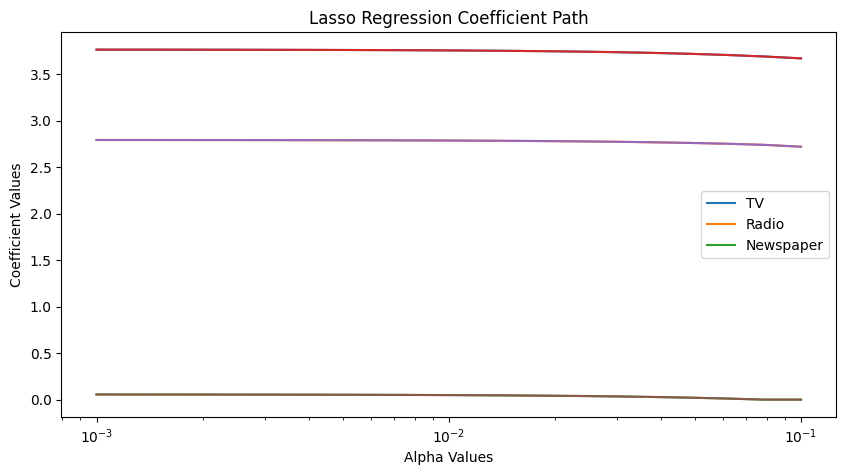

In [8]:
alphas = np.logspace(-3,-1,20)
coefficients_path = []

for alpha_value in alphas:
  lasso = Lasso(alpha=alpha_value,max_iter=5000)
  lasso.fit(X_train,y_train)
  coefficients_path.append(lasso.coef_)

  print(f"Alpha = {alpha_value:.4f} | Coefficients = {lasso.coef_}")

coefficients_path = np.array(coefficients_path)

plt.figure(figsize=(10,5))
plt.plot(alphas,coefficients_path)
plt.xscale("log")
plt.plot(alphas,coefficients_path)
plt.xlabel("Alpha Values")
plt.ylabel("Coefficient Values")
plt.title("Lasso Regression Coefficient Path")
plt.legend(X.columns)
plt.show()